In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
camera_logic = camera_logic
camera_hardware = camera_SPC3

NameError: name 'camera_logic' is not defined

In [4]:
camera_hardware._NFrames = 1 
camera_hardware._apply_camera_settings() 

In [5]:
frames = camera_logic.capture_frame() # Returns (counters, frames, rows, cols)
single_frame = camera_logic.last_frame

In [6]:
camera_logic.set_snap_frames(1)  # wraps _apply_camera_settings
cam = camera_logic._camera()
print("NFrames set:", cam._NFrames)

frames = camera_logic.start_single_acquisition()
print("frames.shape:", frames.shape)

# Use only the requested frame
frames = frames[:, :1, :, :]
single_frame = frames[0, 0]

NFrames set: 1
frames.shape: (1, 2, 32, 32)


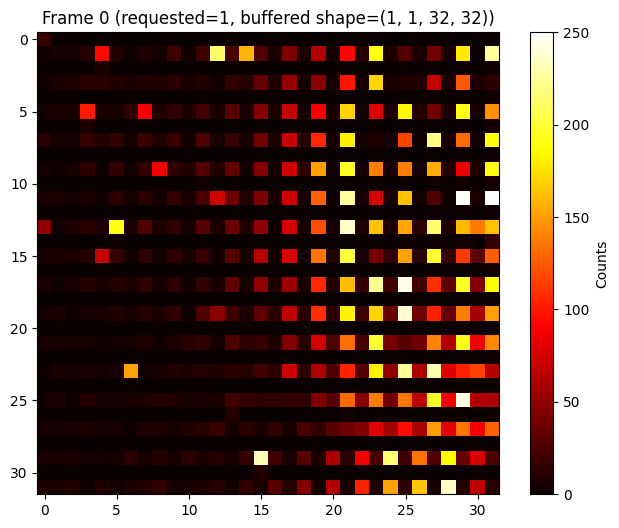

In [7]:
camera_logic.set_snap_frames(1)          # ensure NFrames=1 applied
frames = camera_logic.start_single_acquisition()  # (counters, frames, rows, cols)
frames = frames[:, :1, :, :]             # crop to requested frames
single_frame = frames[0, 0]

plt.figure(figsize=(8, 6))
plt.imshow(single_frame, cmap="hot")
plt.colorbar(label="Counts")
plt.title(f"Frame 0 (requested=1, buffered shape={frames.shape})")
plt.show()

Full frames shape: (1, 2, 32, 32)
Data type: uint8
Requested frames: 1


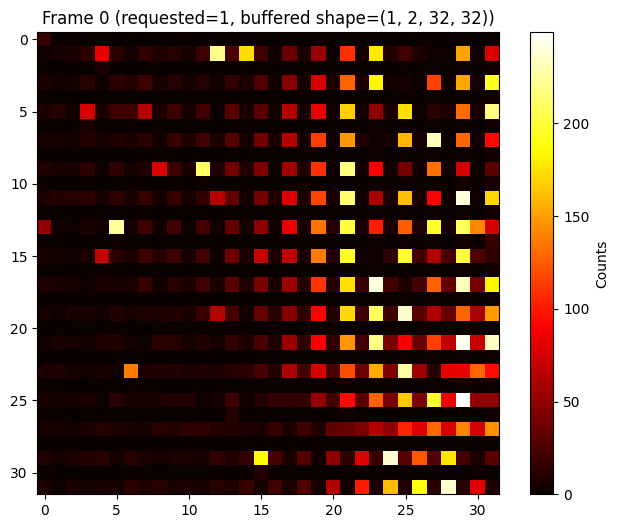

In [30]:
print(f"Full frames shape: {frames.shape}")
print(f"Data type: {frames.dtype}")
print(f"Requested frames: {camera_hardware._NFrames}")

# Bring frames local (avoid rpyc proxy) and crop to requested frames
num_requested = camera_hardware._NFrames
actual_frames = frames[:, :num_requested, :, :]  # shape (counters, frames, rows, cols")

# Display first frame (counter 0, frame 0)
plt.figure(figsize=(8, 6))
plt.imshow(actual_frames[0, 0, :, :], cmap='hot')
plt.colorbar(label='Counts')
plt.title(f'Frame 0 (requested={num_requested}, buffered shape={frames.shape})')
plt.show()

In [19]:
frame1 = frames[:, 0, :, :]
frame2 = frames[:, 1, :, :]
frame = frame1 - frame2

In [ ]:
# Safe snap: ensure idle, set NFrames=1, stop live, then acquire
cam = camera_logic._camera()
if getattr(cam, "_live", False) or getattr(cam, "_acquiring", False):
    try:
        cam.stop_acquisition()
        print("Stopped live/acquiring.")
    except Exception as e:
        print("Warning: stop_acquisition failed:", e)

camera_logic.set_snap_frames(1)

frames = camera_logic.start_single_acquisition()
if frames is None:
    raise RuntimeError("start_single_acquisition returned None")

requested = getattr(cam, "_NFrames", frames.shape[1] if frames is not None else 0)
frames = frames[:, :requested, :, :]

if frames.shape[1] == 0:
    state = camera_logic.module_state() if hasattr(camera_logic, "module_state") else "unknown"
    raise RuntimeError(f"Snap returned zero frames; _NFrames={requested}, state={state}")

single_frame = frames[0, 0, :, :]
print("Single frame shape:", single_frame.shape, "dtype:", single_frame.dtype, "min:", single_frame.min(), "max:", single_frame.max())

1
32
32


In [3]:
camera._NFrames = 1 
camera._apply_camera_settings() 

In [6]:
spc3.SnapPrepare()
spc3.SnapAcquire()
frames = spc3.SnapGetImageBuffer()  

In [7]:
frames.shape

AttributeError: 'NoneType' object has no attribute 'shape'

Full frames shape: (1, 2, 32, 32)
Data type: uint8
Requested frames: 1
Cropped frames shape: (1, 1, 32, 32)


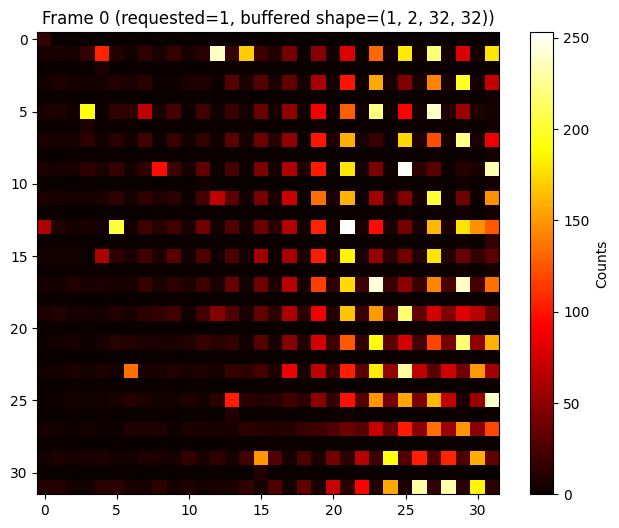

In [7]:
print(f"Full frames shape: {frames.shape}")
print(f"Data type: {frames.dtype}")
print(f"Requested frames: {camera._NFrames}")

# Extract only the requested number of frames (discard buffer padding)
num_requested = camera._NFrames
actual_frames = frames[:, :num_requested, :, :]
print(f"Cropped frames shape: {actual_frames.shape}")

# Display first frame
plt.figure(figsize=(8, 6))
plt.imshow(actual_frames[0, 0, :, :], cmap='hot')
plt.colorbar(label='Counts')
plt.title(f'Frame 0 (requested={num_requested}, buffered shape={frames.shape})')
plt.show()
